# Explainability — SHAP + Risk Scoring


**"Why did the model flag this job as a scam?"**

1. **Global explainability** — which features matter most across all postings
2. **Local explainability** — why THIS specific posting was flagged
3. **Risk scorecard** — Low / Medium / High tiers with evidence bullets
4. **Export** — scored dataset ready for Power BI



In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import sqlite3
import warnings
warnings.filterwarnings('ignore')

os.makedirs("outputs", exist_ok=True)
import os

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2d3154',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2d3154',
    'grid.linewidth':   0.5,
})

ACCENT = '#7c6af7'
RED    = '#ef4444'
GREEN  = '#10b981'
YELLOW = '#f59e0b'

print(" Imports done")

 Imports done


In [17]:
import os
print(os.getcwd())

c:\Users\gsure\Downloads\AI-Powered Recruitment Fraud Analytics & Risk Scoring\notebooks


In [22]:
import os

path = "outputs/best_model.pkl"

print(os.path.exists(path))

True


In [23]:
# Load model
best_model = joblib.load("outputs/best_model.pkl")
opt_threshold = np.load("outputs/optimal_threshold.npy")[0]

# Load features
data = np.load("../notebooks/data/features.npz")
X             = data['X']
y             = data['y']
feature_names = np.load("../notebooks/data/feature_names.npy", allow_pickle=True).tolist()

# Load full dataframe (for context in explanations)
df = pd.read_csv("../notebooks/data/df_engineered.csv")

# Split same way as notebook 3 — same random_state = same split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
_, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=y
)
df_test = df_test.reset_index(drop=True)

print(f"    Model loaded: {type(best_model).__name__}")
print(f"    Optimal threshold: {opt_threshold:.3f}")
print(f"    Test set: {X_test.shape[0]:,} rows")
print(f"    Feature count: {len(feature_names)}")

    Model loaded: XGBClassifier
    Optimal threshold: 0.273
    Test set: 3,576 rows
    Feature count: 317


## Step 1 — Compute SHAP Values

SHAP (SHapley Additive exPlanations) assigns each feature
a value showing how much it pushed the prediction toward
scam (positive) or toward legit (negative).



In [24]:
print("Computing SHAP values — this takes 1-2 minutes...")

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Random Forest returns list of 2 arrays [class0, class1]
# XGBoost returns single array
# We always want class 1 = fraudulent
if isinstance(shap_values, list):
    sv = shap_values[1]   # fraud class
else:
    sv = shap_values

print(f"    SHAP values computed")
print(f"    Shape: {sv.shape}  (test rows × features)")
print(f"    Each value = how much that feature pushed toward SCAM")

Computing SHAP values — this takes 1-2 minutes...
    SHAP values computed
    Shape: (3576, 317)  (test rows × features)
    Each value = how much that feature pushed toward SCAM


## Step 2 — Global Explainability

**Beeswarm plot** — shows every test posting as a dot.
- Position on X axis = SHAP value (how much it pushed toward scam)


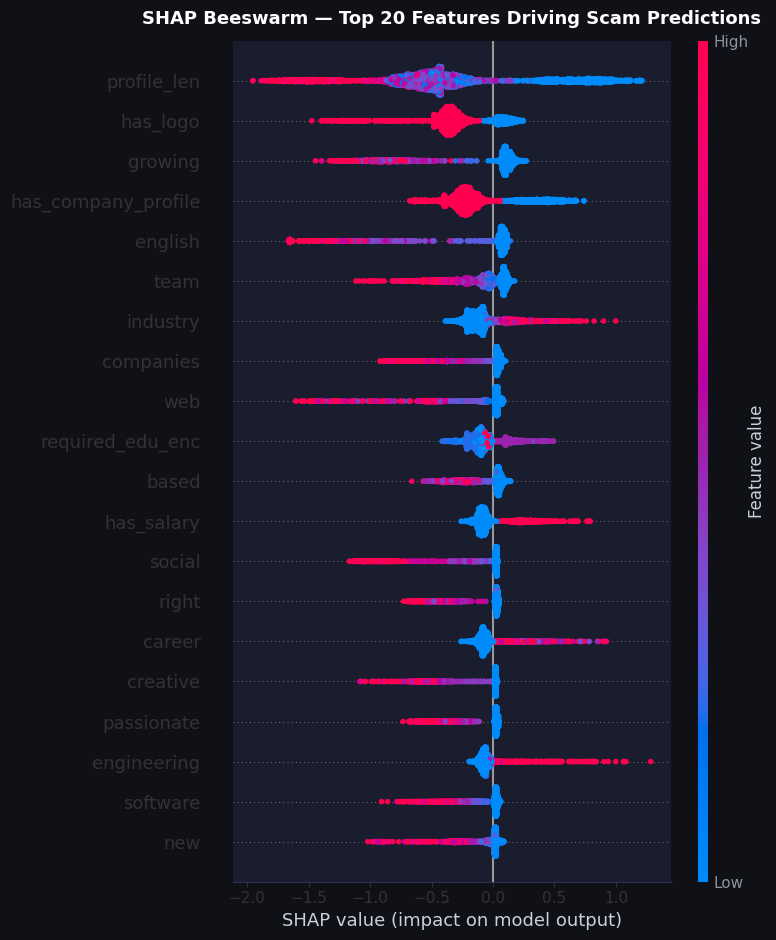

  Saved: ./outputs/shap_beeswarm.png


In [28]:
fig = plt.figure(figsize=(12, 9))
fig.patch.set_facecolor('#0f1117')

shap.summary_plot(
    sv,
    X_test,
    feature_names=feature_names,
    max_display=20,
    show=False,
    plot_type='dot'
)

plt.title('SHAP Beeswarm — Top 20 Features Driving Scam Predictions',
          fontsize=13, fontweight='bold', color='white', pad=12)
plt.tight_layout()
plt.savefig('./outputs/shap_beeswarm.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("  Saved: ./outputs/shap_beeswarm.png")


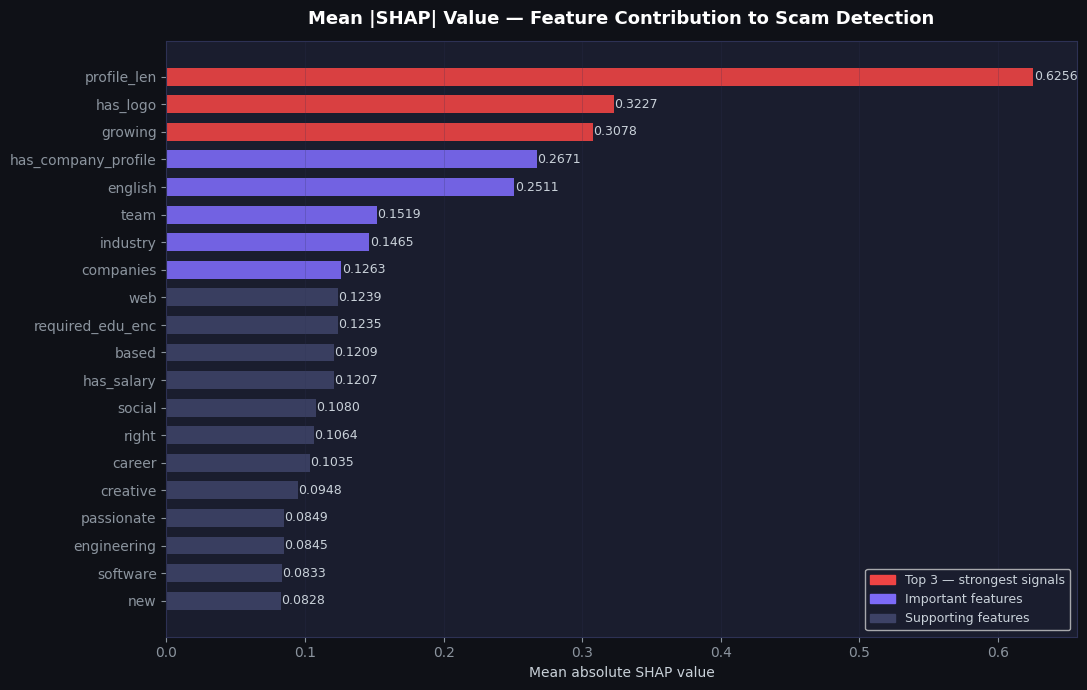

  Saved: ./outputs/shap_bar.png


In [27]:
mean_shap = pd.Series(
    np.abs(sv).mean(axis=0),
    index=feature_names
).nlargest(20)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

bar_colors = [RED if i < 3 else ACCENT if i < 8
              else '#3d4266' for i in range(len(mean_shap))]

bars = ax.barh(
    mean_shap.index[::-1],
    mean_shap.values[::-1],
    color=bar_colors[::-1],
    alpha=0.9,
    height=0.65
)

for bar, val in zip(bars, mean_shap.values[::-1]):
    ax.text(bar.get_width() + 0.0002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center',
            fontsize=9, color='#c9d1d9')

ax.set_title('Mean |SHAP| Value — Feature Contribution to Scam Detection',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Mean absolute SHAP value', fontsize=10)
ax.grid(axis='x', alpha=0.3)

# Legend
patches = [
    mpatches.Patch(color=RED,     label='Top 3 — strongest signals'),
    mpatches.Patch(color=ACCENT,  label='Important features'),
    mpatches.Patch(color='#3d4266', label='Supporting features'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('./outputs/shap_bar.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("  Saved: ./outputs/shap_bar.png")

## Step 3 — Local Explainability

Local explainability tells us **why THIS specific posting
was flagged** — the feature values that pushed it toward scam.

- A real scam posting from the dataset
- A real legit posting from the dataset


In [30]:
# Human-readable labels for structured features
HUMAN_LABELS = {
    'has_company_profile': 'Company profile missing',
    'has_salary':          'Salary range not disclosed',
    'has_requirements':    'No job requirements listed',
    'has_benefits':        'No benefits mentioned',
    'has_logo':            'No company logo',
    'telecommuting':       'Remote/telecommuting role',
    'urgency_count':       'Urgency language detected',
    'money_flag_count':    'Upfront payment language',
    'vague_count':         'Vague income promises',
    'credential_count':    '"No experience required" claim',
    'desc_len':            'Job description length',
    'profile_len':         'Company profile length',
    'req_len':             'Requirements section length',
    'title_word_cnt':      'Words in job title',
    'employment_type_enc': 'Employment type',
    'required_exp_enc':    'Required experience level',
    'required_edu_enc':    'Required education level',
}

def explain_single(idx, X_data, df_data, sv_data, threshold):
    """
    Print a full plain-English explanation for one posting.
    idx = row index in test set
    """
    prob      = best_model.predict_proba(X_data[idx:idx+1])[0][1]
    tier      = ('🔴 HIGH'   if prob > 0.60 else
                 '🟡 MEDIUM' if prob > threshold else
                 '🟢 LOW')
    row       = df_data.iloc[idx]
    shap_row  = sv_data[idx]

    contrib   = pd.Series(shap_row, index=feature_names)
    top_scam  = contrib.nlargest(6)
    top_legit = contrib.nsmallest(3)

    print("=" * 56)
    print(f"  JOB TITLE : {row.get('title','N/A')[:50]}")
    print(f"  INDUSTRY  : {row.get('industry','N/A')}")
    print(f"  ACTUAL    : {'⚠️  SCAM' if row['fraudulent']==1 else '✅  LEGIT'}")
    print(f"  PREDICTED : {tier} RISK  ({prob*100:.1f}% scam probability)")
    print("=" * 56)

    print("\n   RED FLAGS (pushing toward SCAM):")
    for feat, val in top_scam.items():
        label = HUMAN_LABELS.get(feat, feat)
        bar   = '█' * min(int(abs(val) * 500), 20)
        print(f"     {bar}  {label}  (+{val:.4f})")

    print("\n   LEGITIMACY SIGNALS (pushing toward LEGIT):")
    for feat, val in top_legit.items():
        label = HUMAN_LABELS.get(feat, feat)
        bar   = '█' * min(int(abs(val) * 500), 20)
        print(f"     {bar}  {label}  ({val:.4f})")

    print()
    return prob, tier

In [31]:
# Find a high-confidence scam in test set
scam_indices  = np.where(y_test == 1)[0]
probs_test    = best_model.predict_proba(X_test)[:, 1]

# Pick the scam the model is most confident about
top_scam_idx  = scam_indices[
    np.argmax(probs_test[scam_indices])
]

print("EXAMPLE 1 — HIGH CONFIDENCE SCAM\n")
explain_single(top_scam_idx, X_test, df_test, sv, opt_threshold)

EXAMPLE 1 — HIGH CONFIDENCE SCAM

  JOB TITLE : Data Entry Admin/Clerical Positions - Work From Ho
  INDUSTRY  : nan
  ACTUAL    : ⚠️  SCAM
  PREDICTED : 🔴 HIGH RISK  (99.7% scam probability)

   RED FLAGS (pushing toward SCAM):
     ████████████████████  Company profile length  (+1.1125)
     ████████████████████  Company profile missing  (+0.6588)
     ████████████████████  Vague income promises  (+0.4413)
     ████████████████████  home  (+0.3862)
     ████████████████████  school  (+0.3506)
     ████████████████████  multi  (+0.3213)

   LEGITIMACY SIGNALS (pushing toward LEGIT):
     ████████████████████  able  (-0.1641)
     ████████████████████  multiple  (-0.0645)
     ████████████████████  industry  (-0.0629)



(np.float32(0.9973195), '🔴 HIGH')

In [32]:
# Find a high-confidence legit posting
legit_indices = np.where(y_test == 0)[0]
top_legit_idx = legit_indices[
    np.argmin(probs_test[legit_indices])
]

print("EXAMPLE 2 — HIGH CONFIDENCE LEGIT\n")
explain_single(top_legit_idx, X_test, df_test, sv, opt_threshold)

EXAMPLE 2 — HIGH CONFIDENCE LEGIT

  JOB TITLE : Software Engineer for Games
  INDUSTRY  : Computer Games
  ACTUAL    : ✅  LEGIT
  PREDICTED : 🟢 LOW RISK  (0.0% scam probability)

   RED FLAGS (pushing toward SCAM):
     ████████████████████  platform  (+0.1030)
     ████████████████████  people  (+0.0871)
     ████████████████████  years  (+0.0681)
     ████████████████████  motivated  (+0.0629)
     ████████████████████  field  (+0.0576)
     ████████████████  problems  (+0.0334)

   LEGITIMACY SIGNALS (pushing toward LEGIT):
     ████████████████████  Company profile length  (-1.3066)
     ████████████████████  growing  (-0.6056)
     ████████████████████  team  (-0.5741)



(np.float32(4.454251e-05), '🟢 LOW')

## Step 4 — Risk Scorecard

Assign every posting to a risk tier:
-  **Low** — predicted probability < 25%
-  **Medium** — 25% to 60%
-  **High** — above 60%




In [33]:
# Score the entire dataset (not just test set)
all_probs = best_model.predict_proba(X)[:, 1]

df['predicted_prob'] = all_probs
df['risk_tier'] = pd.cut(
    df['predicted_prob'],
    bins=[0, 0.25, 0.60, 1.0],
    labels=['Low', 'Medium', 'High']
)

# Validation table
tier_stats = df.groupby('risk_tier', observed=True).agg(
    total_postings   = ('job_id',         'count'),
    actual_scams     = ('fraudulent',      'sum'),
    actual_fraud_rate= ('fraudulent',      'mean'),
    avg_pred_prob    = ('predicted_prob',  'mean')
).round(3)

tier_stats['actual_fraud_rate'] = (
    tier_stats['actual_fraud_rate'] * 100
).round(1).astype(str) + '%'

tier_stats['avg_pred_prob'] = (
    tier_stats['avg_pred_prob'] * 100
).round(1).astype(str) + '%'

print("Risk Tier Validation\n")
print(tier_stats.to_string())
print("\n  Fraud rate should increase Low → Medium → High")
print("    If it does, your model is correctly ordered — note these %s")

Risk Tier Validation

           total_postings  actual_scams actual_fraud_rate avg_pred_prob
risk_tier                                                              
Low                 16369            13              0.1%          2.0%
Medium                549            29              5.3%         39.4%
High                  962           824             85.7%         92.1%

  Fraud rate should increase Low → Medium → High
    If it does, your model is correctly ordered — note these %s


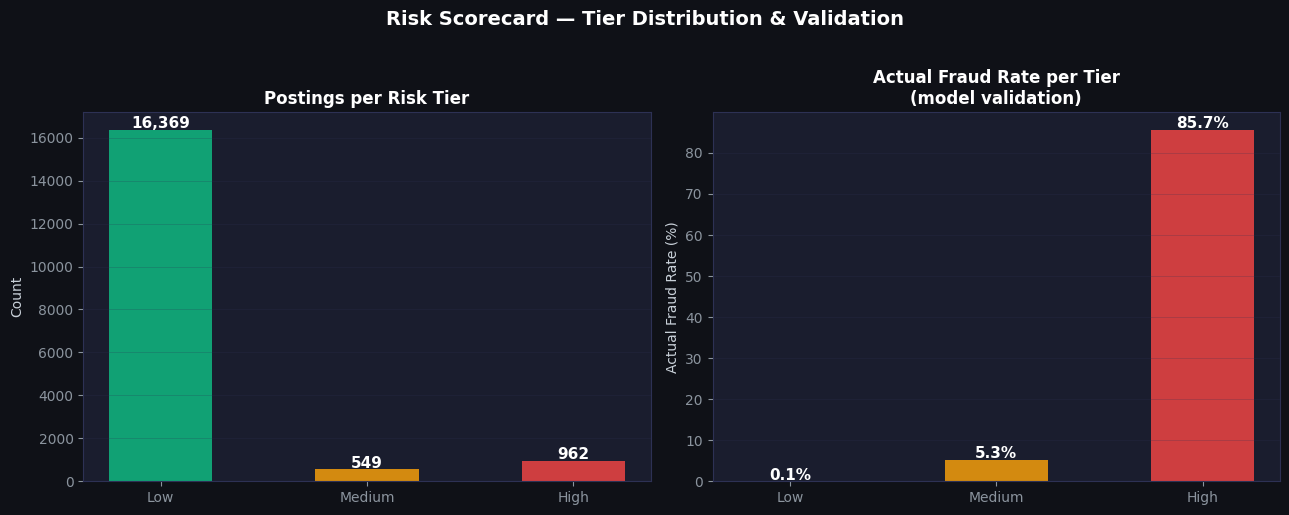

  Saved: ./outputs/risk_tiers.png


In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d2e')
    ax.grid(axis='y', alpha=0.3)

tier_colors  = {'Low': GREEN, 'Medium': YELLOW, 'High': RED}
tier_counts  = df['risk_tier'].value_counts().reindex(
    ['Low','Medium','High'])
tier_fraud   = df.groupby('risk_tier', observed=True)['fraudulent'].mean() * 100
tier_fraud   = tier_fraud.reindex(['Low','Medium','High'])

# Left — posting count per tier
bars1 = ax1.bar(
    tier_counts.index,
    tier_counts.values,
    color=[tier_colors[t] for t in tier_counts.index],
    alpha=0.85, width=0.5
)
for bar, val in zip(bars1, tier_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 80,
             f'{val:,}', ha='center',
             fontsize=11, color='white', fontweight='bold')
ax1.set_title('Postings per Risk Tier',
              fontsize=12, fontweight='bold', color='white')
ax1.set_ylabel('Count', fontsize=10)

# Right — actual fraud rate per tier
bars2 = ax2.bar(
    tier_fraud.index,
    tier_fraud.values,
    color=[tier_colors[t] for t in tier_fraud.index],
    alpha=0.85, width=0.5
)
for bar, val in zip(bars2, tier_fraud.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center',
             fontsize=11, color='white', fontweight='bold')
ax2.set_title('Actual Fraud Rate per Tier\n(model validation)',
              fontsize=12, fontweight='bold', color='white')
ax2.set_ylabel('Actual Fraud Rate (%)', fontsize=10)

fig.suptitle('Risk Scorecard — Tier Distribution & Validation',
             fontsize=14, fontweight='bold', color='white', y=1.02)

plt.tight_layout()
plt.savefig('./outputs/risk_tiers.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("  Saved: ./outputs/risk_tiers.png")

In [35]:
export_cols = [
    'job_id', 'title', 'industry', 'employment_type',
    'location', 'required_experience', 'required_education',
    'has_company_profile', 'has_salary', 'has_logo',
    'has_requirements', 'has_benefits', 'telecommuting',
    'urgency_count', 'money_flag_count', 'vague_count',
    'credential_count', 'desc_len', 'profile_len',
    'predicted_prob', 'risk_tier', 'fraudulent'
]

export_df = df[[c for c in export_cols if c in df.columns]].copy()
export_df['predicted_prob'] = (
    export_df['predicted_prob'] * 100
).round(1)

export_df.to_csv('./outputs/powerbi_job_scores.csv', index=False)

# Industry summary for Power BI page 2
industry_summary = df.groupby('industry', observed=True).agg(
    total_postings  = ('job_id',          'count'),
    scam_count      = ('fraudulent',       'sum'),
    fraud_rate_pct  = ('fraudulent',       'mean'),
    avg_risk_score  = ('predicted_prob',   'mean')
).reset_index()

industry_summary['fraud_rate_pct'] = (
    industry_summary['fraud_rate_pct'] * 100
).round(1)
industry_summary['avg_risk_score'] = (
    industry_summary['avg_risk_score'] * 100
).round(1)
industry_summary = industry_summary[
    industry_summary['industry'].str.strip() != ''
].sort_values('fraud_rate_pct', ascending=False)

industry_summary.to_csv(
    './outputs/powerbi_industry_summary.csv', index=False)

print("   Exported for Power BI:")
print("    ./outputs/powerbi_job_scores.csv       ← main scored dataset")
print("    ./outputs/powerbi_industry_summary.csv ← industry breakdown")
print(f"\n    Total rows exported: {len(export_df):,}")
print(f"    High risk flagged:   {(export_df['risk_tier']=='High').sum():,}")
print(f"    Medium risk:         {(export_df['risk_tier']=='Medium').sum():,}")
print(f"    Low risk:            {(export_df['risk_tier']=='Low').sum():,}")

   Exported for Power BI:
    ./outputs/powerbi_job_scores.csv       ← main scored dataset
    ./outputs/powerbi_industry_summary.csv ← industry breakdown

    Total rows exported: 17,880
    High risk flagged:   962
    Medium risk:         549
    Low risk:            16,369
